Задача 1

Напишите функцию в Python, которая генерирует список из 1000 случайных чисел из нормального распределения с заданными параметрами: среднее и стандартное отклонение. Затем постройте гистограмму и график плотности распределения для сгенерированных данных.

Вычислите основные статистики — среднее, медиана, стандартное отклонение, а затем выведите их на экран.

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import random
import math

count    1000.000000
mean       49.388588
std         9.954570
min        10.960515
25%        42.705164
50%        49.306996
75%        56.232115
max        77.561389
dtype: float64

Медиана: 49.30699571319239


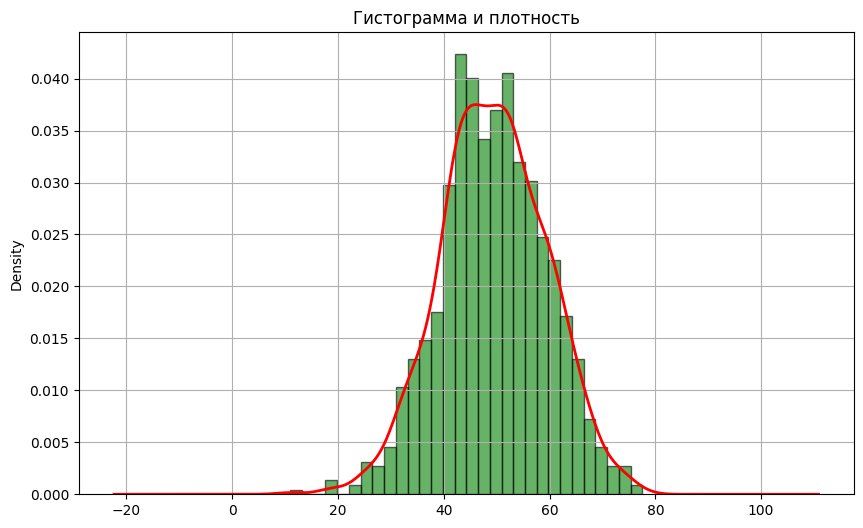

In [ ]:
# 1. Генерируем список
mean, std_dev = 50, 10
numbers = np.random.normal(mean, std_dev, 1000)

# Переводим данные в таблицу (Series) pandas
df = pd.Series(numbers)

# 2. Расчет среднего и стандартное отклонение, медиана
print(df.describe())
print(f"\nМедиана: {df.median()}")

# 3. График плотности и гистограмма
plt.figure(figsize=(10, 6))

df.plot(kind='hist', bins=30, density=True, alpha=0.6, color='green', edgecolor='black')
# Накладываем график плотности (KDE)
df.plot(kind='kde', color='red', linewidth=2)

plt.title("Гистограмма и плотность")
plt.grid(True)
plt.show()

Задача 2

Что нужно сделать:

Построить распределение клиентских платежей с помощью гистограммы и, применив правила трех сигм (а также одной и двух сигм), оценить, насколько данное распределение похоже на нормальное.
Провести такой же анализ близости к нормальному распределению для каждого типа устройства клиентов по отдельности. Платежи по какому типу устройства больше всего похожи на нормальное распределение?
Создайте датафрейм df_res со следующей структурой:

Колонки:
Процент выборки внутри интервала «среднее плюс-минус одна сигма (1sigma)».
Процент выборки внутри интервала «среднее плюс-минус две сигмы (2sigma)».
Процент выборки внутри интервала «среднее плюс-минус три сигмы (3sigma)».
Разница по сравнению с соответствующим показателем нормального распределения — 68% (diff1sigma).
Разница по сравнению с соответствующим показателем нормального распределения — 95% (diff2sigma).
Разница по сравнению с соответствующим показателем нормального распределения — 99,7% (diff3sigma).
Каждая строка показывает свой тип устройства — всего получится три строки.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = '/content/drive/MyDrive/ДЗ распределения в питон/device_client.csv'
dc = pd.read_csv(path)
dc.head()

,id_client;type
0,19091;ios
1,18768;PC
2,19080;PC
3,18396;ios
4,18461;ios


In [ ]:
#разделяем колонки
dc[['id_client', 'type']] = dc['id_client;type'].str.split(';',expand=True)
dc = dc.drop(columns=['id_client;type'])
dc.head()

,id_client,type
0,19091,ios
1,18768,PC
2,19080,PC
3,18396,ios
4,18461,ios


In [ ]:
len(dc)

779

In [ ]:
path = '/content/drive/MyDrive/ДЗ распределения в питон/payment_client.csv'
pc = pd.read_csv(path)
pc.head()

,id_client;amt_pay
0,18788;24
1,19059;3743
2,18785;8185
3,18795;2202
4,18818;3377


In [ ]:
len(pc)

779

In [ ]:
#разделяем колонки
pc[['id_client', 'amt_pay']] = pc['id_client;amt_pay'].str.split(';',expand=True)
pc = pc.drop(columns=['id_client;amt_pay'])
pc.head()

,id_client,amt_pay
0,18788,24
1,19059,3743
2,18785,8185
3,18795,2202
4,18818,3377


In [ ]:
print(pc.isna().sum())

id_client    0
amt_pay      0
dtype: int64


In [ ]:
#соединяем две таблицы вместе
df = pd.merge(dc, pc, on='id_client', how='inner')
df.head()


,id_client,type,amt_pay
0,19091,ios,2957
1,18768,PC,86
2,19080,PC,638
3,18396,ios,3891
4,18461,ios,7598


In [27]:
df['amt_pay'].max()

8826

In [28]:
df['amt_pay'] = pd.to_numeric(df['amt_pay'], errors='coerce')

In [29]:
df.dtypes

,0
id_client,object
type,object
amt_pay,int64


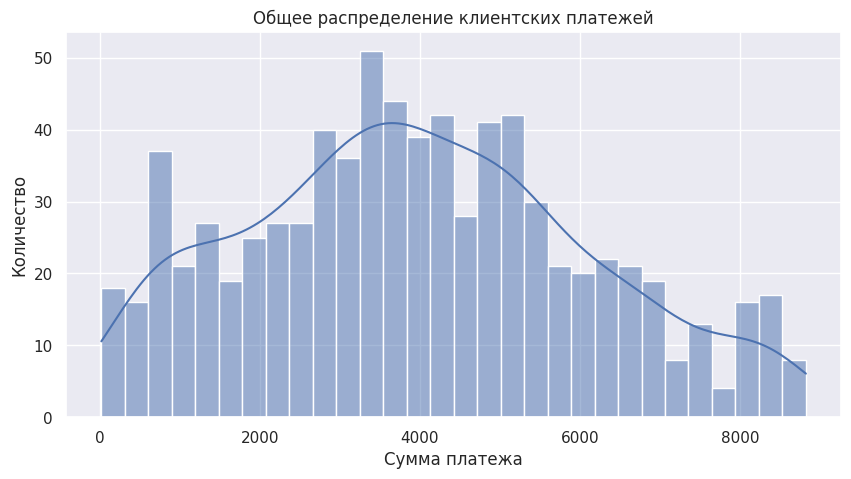

In [35]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="amt_pay", kde=True, bins=30)
plt.title('Общее распределение клиентских платежей')
plt.xlabel('Сумма платежа')
plt.ylabel('Количество')
plt.show()

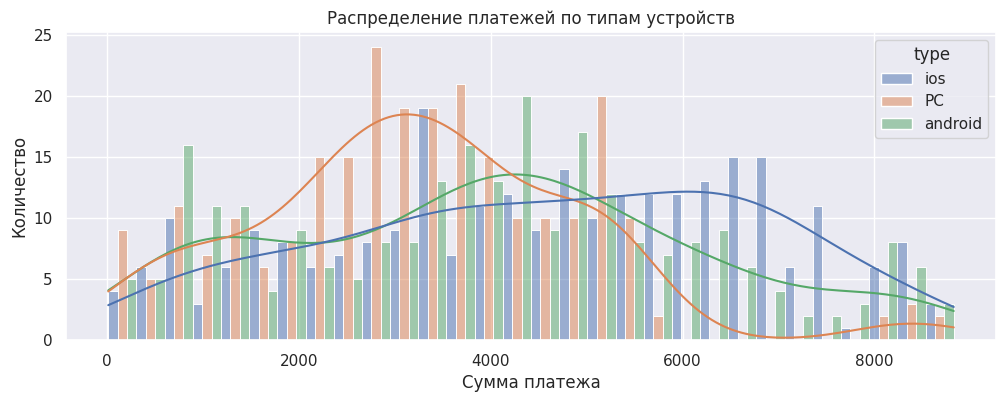

In [36]:
plt.figure(figsize=(12, 4))
sns.histplot(data=df, x="amt_pay", hue="type", kde=True, bins=30, multiple="dodge")
plt.title('Распределение платежей по типам устройств')
plt.xlabel('Сумма платежа')
plt.ylabel('Количество')
plt.show()

In [31]:
m = df['amt_pay'].mean()
s = df['amt_pay'].std()

print('Среднее = ', m)
print('Сигма = ', s)

Среднее =  3961.2182284980745
Сигма =  2124.655341443491


In [50]:
in_1sig = df[(df['amt_pay'] >= m - s) & (df['amt_pay'] <= m + s)]
in_2sig = df[(df['amt_pay'] >= m - 2*s) & (df['amt_pay'] <= m + 2*s)]
in_3sig = df[(df['amt_pay'] >= m - 3*s) & (df['amt_pay'] <= m + 3*s)]

In [51]:
print('Доля наблюдений в 1 сигме', in_1sig.count()['id_client']   / df.count()['id_client'])
print('Доля наблюдений в 2 сигмах', in_2sig.count()['id_client']   / df.count()['id_client'])
print('Доля наблюдений в 3 сигмах', in_3sig.count()['id_client'] / df.count()['id_client'])

Доля наблюдений в 1 сигме 0.6469833119383825
Доля наблюдений в 2 сигмах 0.9666238767650834
Доля наблюдений в 3 сигмах 1.0


In [40]:
df.head()

,id_client,type,amt_pay
0,19091,ios,2957
1,18768,PC,86
2,19080,PC,638
3,18396,ios,3891
4,18461,ios,7598


In [56]:
import pandas as pd
import numpy as np

# Списки для сохранения результатов расчета
devices = []
p_1sig_list = []
p_2sig_list = []
p_3sig_list = []
diff1_list = []
diff2_list = []
diff3_list = []

# Перебираем каждый тип устройства в вашей таблице
for dev_type in df['type'].unique():
    # Берем платежи только для текущего устройства
    sub_data = df[df['type'] == dev_type]['amt_pay']

    # Считаем среднее и стандартное отклонение (сигму)
    mean_val = sub_data.mean()
    std_val = sub_data.std()
    total = len(sub_data)

    # Считаем, сколько платежей попало в границы сигм
    in_1 = ((sub_data >= mean_val - std_val) & (sub_data <= mean_val + std_val)).sum()
    in_2 = ((sub_data >= mean_val - 2*std_val) & (sub_data <= mean_val + 2*std_val)).sum()
    in_3 = ((sub_data >= mean_val - 3*std_val) & (sub_data <= mean_val + 3*std_val)).sum()

    # Переводим в проценты
    p_1 = (in_1 / total) * 100
    p_2 = (in_2 / total) * 100
    p_3 = (in_3 / total) * 100

    # Сохраняем результаты в списки
    devices.append(dev_type)
    p_1sig_list.append(p_1)
    p_2sig_list.append(p_2)
    p_3sig_list.append(p_3)

    # Считаем разницу с эталоном (68%, 95%, 99.7%)
    diff1_list.append(abs(p_1 - 68.0))
    diff2_list.append(abs(p_2 - 95.0))
    diff3_list.append(abs(p_3 - 99.7))

# Создаем итоговый датафрейм df_res строго по колонкам из задания
df_res = pd.DataFrame({
    '1sigma': p_1sig_list,
    '2sigma': p_2sig_list,
    '3sigma': p_3sig_list,
    'diff1sigma': diff1_list,
    'diff2sigma': diff2_list,
    'diff3sigma': diff3_list
}, index=devices)

# Выводим готовую таблицу
df_res

,1sigma,2sigma,3sigma,diff1sigma,diff2sigma,diff3sigma
ios,62.867647,98.897059,100.000000,5.132353,3.897059,0.300000
PC,66.798419,97.233202,98.023715,1.201581,2.233202,1.676285
android,62.992126,98.031496,100.000000,5.007874,3.031496,0.300000
